# **Diplomado IA: Deep Learning 1 - Parte 1**. <br> Práctico 11: Redes Recurrentes
---
---

**Profesores:**
- Alain Raymond
- Carlos Aspillaga


El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**

El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Detección de nacionalidad a partir de apellidos utilizando RNNs a nivel de caracteres

Parcialmente basado en:

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/

https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

https://pytorch.org/tutorials/beginner/former_torchies/nn_tutorial.html#example-2-recurrent-net

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html

https://github.com/donnemartin/data-science-ipython-notebooks/blob/master/deep-learning/keras-tutorial/3.2%20RNN%20and%20LSTM.ipynb

http://juditacs.github.io/2018/12/27/masked-attention.html

Construiremos y entrenaremos Redes Neuronales Recurrentes (RNNs) básicas a nivel de caracteres para clasificar palabras. Intencionalmente este laboratorio no utiliza muchas de las funciones de conveniencia de `torchtext`, para permitir observar la operatoria a bajo nivel.

Una RNN a nivel de caracteres lee palabras como una serie de caracteres, emitiendo una predicción y un "estado oculto" en cada paso, alimentando su estado oculto previo en cada siguiente paso. Tomamos la predicción final proyectada linealmente como la salida, para indicar a qué clase pertenece la palabra.

Específicamente, entrenaremos en unos pocos miles de nombres de 18 idiomas de origen, y prediremos a qué idioma pertenece un nombre basándonos en la ortografía.


## Los Datos

Primero vamos a descargar y descomprimir los datos

In [ ]:
%matplotlib inline

In [ ]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip

--2025-11-13 23:44:33--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 143.204.160.115, 143.204.160.84, 143.204.160.77, ...
Connecting to download.pytorch.org (download.pytorch.org)|143.204.160.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.05s   

2025-11-13 23:44:33 (61.0 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/na

Dentro del directorio ``data/names`` existen 18 archivos de texto con nombre ``[Language].txt``. Cada archivo contiene una serie de nombres, un nombre por línea, en su mayoría romanizados (pero aún necesitamos convertir de Unicode a ASCII).

Luego de ejecutar la siguiente celda, terminaremos con un diccionario de listas de nombres por idioma,
``{language: [names ...]}``.

In [ ]:
from io import open
import glob
import os
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def findFiles(path):
    return glob.glob(path)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    # example: this code converts 'Ślusàrski' into 'Slusarski
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Ahora tenemos ``category_lines``, un diccionario que asigna cada categoría (idioma) a una lista de líneas (nombres). También llevamos un registro de ``all_categories`` (simplemente una lista de idiomas) y ``n_categories`` para referencia posterior.




In [ ]:
print(category_lines['French'][:5])

['Abel', 'Abraham', 'Adam', 'Albert', 'Allard']


### Convirtiendo los Nombres en Tensores

Ahora que tenemos todos los nombres organizados, necesitamos convertirlos en Tensores para poder utilizarlos.

Para representar una sola letra, utilizamos un vector "one-hot" de tamaño ``<1 x n_letras>``. Un vector one-hot está lleno de ceros, excepto por un 1 en el índice de la letra actual, por ejemplo, ``"b" = <0 1 0 0 0 ...>``.

Para formar una palabra, unimos varios de estos vectores en una matriz 2D ``<largo_palabra x 1 x n_letras>``.

Esa dimensión adicional de 1 se debe a que PyTorch asume que todo está en batches - aquí estamos utilizando un tamaño de batch de 1 solamente.


In [ ]:
import torch

# Find letter index from all_letters, e.g. "a" = 0

def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(letterToTensor('A'))
print(lineToTensor('AlainRaymond').shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([12, 1, 57])


## Creando una RNN "vanilla"

Este módulo RNN consta simplemente de 2 capas lineales que operan sobre una entrada y un estado oculto.




**Elman RNN Cell** (vanilla RNN cell)

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png)

from colah.github.io

<br>

___

<br>

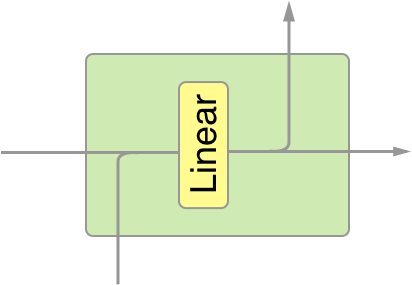


In [ ]:
import torch.nn as nn


class RNNCell(nn.Module):
    """
    Implementation of Elman RNN cell (vanilla RNN cell).
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.hidden_size = hidden_size

        # model layers (input to hidden)
        self.x2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    # RNN forward pass
    def forward(self, input, old_hidden):
        """
        input shaped (batch, input_size)
        hidden shaped (batch, hidden_size)
        """
        # run linear layer on combined inputs (batch, hidden_size)
        hidden = torch.tanh(self.x2h(input) + self.h2h(old_hidden))
        output = self.h2o(hidden)

        return output, hidden

class RNN(nn.Module):
    """
    Implementation of full Elman RNN.
    Executes RNNCell for each of the inputs.
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size, output_size)

    # initialize first hidden state
    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

    # RNN forward pass
    def forward(self, input, hidden): # batch_size, (largo_secuencia x dim_elemento_secuencia)
        # run cell on ith input (batch, hidden_size)
        output, hidden = self.cell(input, hidden)
        return output, hidden

## Creando una RNN tipo LSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch. Solamente nos preocuparemos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM.

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

from https://colah.github.io/posts/2015-08-Understanding-LSTMs

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.cell(input, hidden)
        output = self.h2o(hidden[0])
        return output, hidden

## Creando una RNN tipo BiLSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch, que asumiremos será llamado con un input leido de derecha a izquierda y otro de izquierda a derecha. Debemos preocuparnos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM-forward concatenada con la backward.

![](https://miro.medium.com/max/764/1*6QnPUSv_t9BY9Fv8_aLb-Q.png)

Source: https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = True
        self.hidden_size = hidden_size
        self.forward_cell = nn.LSTMCell(input_size, hidden_size)
        self.backward_cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(2*hidden_size, output_size)

    def init_hidden(self):
        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)), (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size))

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.forward_cell(input[0], hidden[0]), self.backward_cell(input[1], hidden[1])

        # Stack outputs
        outputs_forward = hidden[0][0]
        outputs_backward = hidden[1][0]
        output = self.h2o(torch.cat((outputs_forward, outputs_backward), dim=1))

        return output, hidden



## Ahora analicemos una RNN

In [ ]:
n_hidden = 32

rnn = RNN(n_letters, n_hidden, n_categories)

In [ ]:
print(num_trainable_parameters(rnn))

3506


Para ejecutar un paso de esta red, necesitamos pasar una entrada (en nuestro caso, el tensor para la letra actual) y un estado oculto anterior (que inicializamos como ceros al principio). Obtendremos la salida (probabilidad de cada idioma, antes de softmax) y un siguiente estado oculto (que conservamos para el siguiente paso).

La razón para omitir la softmax es porque utilizaremos una implementación de CrossEntropy que tiene la softmax incorporada. Por lo mismo, si queremos visualizar las probabilidades tendremos que aplicar una softmax manualmente sobre este vector. En nuestro caso no es necesario pues solo nos interesa quedarnos con el índice del máximo (que será el mismo si aplicamos o no la softmax)




In [ ]:
input = letterToTensor('A')
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input, hidden)
print(output, output.shape,next_hidden, next_hidden.shape)

torch.Size([1, 57])
tensor([[-0.1117, -0.2078, -0.0583, -0.1128, -0.2557, -0.0402, -0.0292,  0.0504,
          0.0728, -0.0959,  0.1447,  0.1358,  0.1107, -0.1960, -0.1541,  0.0755,
         -0.1738,  0.0311]], grad_fn=<AddmmBackward0>) torch.Size([1, 18]) tensor([[ 0.0873, -0.0605,  0.2299,  0.0023, -0.1281,  0.0906,  0.2426, -0.1121,
         -0.0400,  0.0194, -0.0910,  0.2191, -0.0779,  0.0571, -0.0124,  0.0986,
         -0.1264, -0.1642,  0.1100,  0.0067,  0.2913, -0.1135,  0.1206, -0.1933,
         -0.0272, -0.2560,  0.0051,  0.0654, -0.3454, -0.2358,  0.0660, -0.0186]],
       grad_fn=<TanhBackward0>) torch.Size([1, 32])


In [ ]:
input = lineToTensor('Albert')
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input[0], hidden)
print(output)

torch.Size([6, 1, 57])
tensor([[-0.1117, -0.2078, -0.0583, -0.1128, -0.2557, -0.0402, -0.0292,  0.0504,
          0.0728, -0.0959,  0.1447,  0.1358,  0.1107, -0.1960, -0.1541,  0.0755,
         -0.1738,  0.0311]], grad_fn=<AddmmBackward0>)


Podemos notar que el output es un Tensor de ``<1 x n_categories>``, que es el vector de probabilidades antes de aplicarle softmax (más grande significa más probable).

Notar que estamos preservando el output correspondiente al último caracter de la palabra (que encapsula toda la información de caractyeres anteriores), con lo cual estamos pudiendo representar cualquier palabra (independiente de su largo) con un vector de tamaño fijo.




## Preparación para el entrenamiento

Primero definiremos una serie de métodos para analizar las salidas y facilitar
el sampleo de ejemplos de entrenamiento




In [ ]:
import random

def categoryFromOutput(output):
    # this function returns the category corresponding to the max value
    # in the returned probability Tensor
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample(): #Data Loader
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('{}: {}'.format(line, category))

Yanalov: Russian
Middelburg: Dutch
Albrecht: German
Ha: Vietnamese
O'Hara: Irish
Snaaijer: Dutch
Swatchak: Czech
She: Chinese
Murphy: Scottish
Romao: Portuguese


### Entrenamiento

Nota importante: Para evitar tener que trabajar con paddings y detener la iteración de manera distinta para cada elemento del batch según su largo original (antes de paddings) trabajaremos con batches de tamaño 1. Si usted necesita trabajar con batches de mayor tamaño, resulta ser un poco más complejo de implementar (por esa razón lo omitimos de este laboratorio). Para referencia, esto se puede hacer mediante las funcionalidades de torch.nn.utils.rnn llamadas pack_padded_sequence y pad_packed_sequence (tutorial en https://gist.github.com/HarshTrivedi/f4e7293e941b17d19058f6fb90ab0fec)

Para comenzar crearemos nuestro objeto a cargo de evaluar la función de pérdida:





In [ ]:
criterion = nn.CrossEntropyLoss()

A continuación creamos una serie de métodos para entrenar, evaluar y graficar resultados de los modelos.

Cada ciclo de entrenamiento hará lo siguiente:

- Creará los tensores de entrada y objetivo.
- Seteará el estado oculto inicial con valores cero.
- Leerá cada letra de la entrada y mantendrá el estado oculto para entregárselo a la siguiente letra.
- Comparará la salida final con el objetivo.
- Realizará el backpropagation.
- Retornará la salida y la función de pérdida.




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
import math

learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor, model):
    hidden = model.init_hidden()

    model.zero_grad()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate) # SGD HECHO A MANO!!!!

    # optimizer.step()

    return output, loss.item()

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def train_model(model, n_iters=200000, print_every=10000, plot_every=1000):

    # Keep track of losses for plotting
    current_loss = 0
    all_losses = []

    start = time.time()

    for iter in range(1, n_iters + 1):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output, loss = train(category_tensor, line_tensor, model)
        current_loss += loss

        # Print ``iter`` number, loss, name and guess
        if iter % print_every == 0:
            guess, guess_i = categoryFromOutput(output)
            correct = '✓' if guess == category else '✗ (%s)' % category
            print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

        # Add current loss avg to list of losses
        if iter % plot_every == 0:
            all_losses.append(current_loss / plot_every)
            current_loss = 0

    return all_losses, model

def plot_loss(all_losses):
    plt.figure()
    plt.plot(all_losses)


# Just return an output given a line
def evaluate(line_tensor, model):
    hidden = model.init_hidden()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)

    return output


def compute_confusion_matrix(model):
    # Keep track of correct guesses in a confusion matrix
    confusion = torch.zeros(n_categories, n_categories)
    n_confusion = 10000

    # Go through a bunch of examples and record which are correctly guessed
    for i in range(n_confusion):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output = evaluate(line_tensor, model)
        guess, guess_i = categoryFromOutput(output)
        category_i = all_categories.index(category)
        confusion[category_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(n_categories):
        confusion[i] = confusion[i] / confusion[i].sum()

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.numpy())
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + all_categories, rotation=90)
    ax.set_yticklabels([''] + all_categories)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()

### Ahora a entrenar!

Mediante el método ``train_model`` entrenaremos los tres modelos.

NOTA:  Si tiene restricciones de tiempo, puede reducir el parámetro ``n_iters`` a la mitad para que finalice antes. En este caso usaremos 200K iteraciones.

Luego de entrenado graficaremos la trayectoria de la función de pérdida almacenada en ``all_losses``, y finalmente mostraremos la matriz de confusión asociada a las predicciones de cada modelo, usando ``compute_confusion_matrix``.




In [ ]:
n_hidden = 147
model = RNN(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 11s) 0.6653 Slusarczyk / Polish ✓
20000 10% (0m 23s) 0.6414 Bonnaire / French ✓
30000 15% (0m 34s) 1.2559 Bang / Chinese ✗ (Korean)
40000 20% (0m 46s) 0.2066 Yamabe / Japanese ✓
50000 25% (0m 57s) 0.9908 Sloan / Irish ✓
60000 30% (1m 9s) 1.6983 Close / English ✗ (Greek)
70000 35% (1m 21s) 1.5556 Knepp / Dutch ✗ (German)
80000 40% (1m 32s) 2.9149 Petit / Russian ✗ (Spanish)
90000 45% (1m 44s) 1.4141 Kaima / Czech ✗ (Japanese)
100000 50% (1m 55s) 1.1826 Riagain / Dutch ✗ (Irish)
110000 55% (2m 7s) 0.0190 Quan / Chinese ✓
120000 60% (2m 18s) 0.1340 Jang / Korean ✓
130000 65% (2m 30s) 0.1064 Kieu / Vietnamese ✓
140000 70% (2m 41s) 1.4316 Petit / English ✗ (French)
150000 75% (2m 53s) 0.0097 Tzeboev / Russian ✓
160000 80% (3m 4s) 0.0256 Diep / Vietnamese ✓
170000 85% (3m 16s) 0.2674 Amstel / Dutch ✓
180000 90% (3m 27s) 0.4088 Wallace / Scottish ✓
190000 95% (3m 39s) 0.0558 O'Donnell / Irish ✓
200000 100% (3m 50s) 0.0912 Almeida / Portuguese ✓


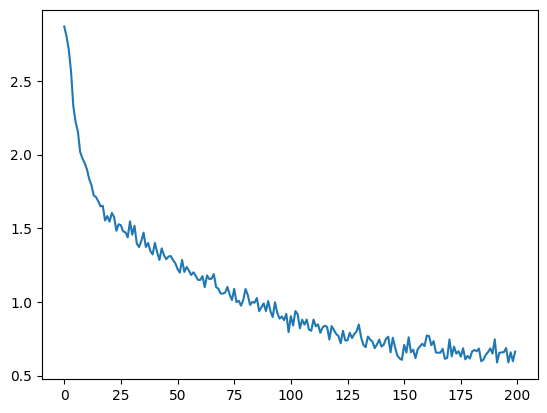

In [ ]:
plot_loss(all_losses)

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


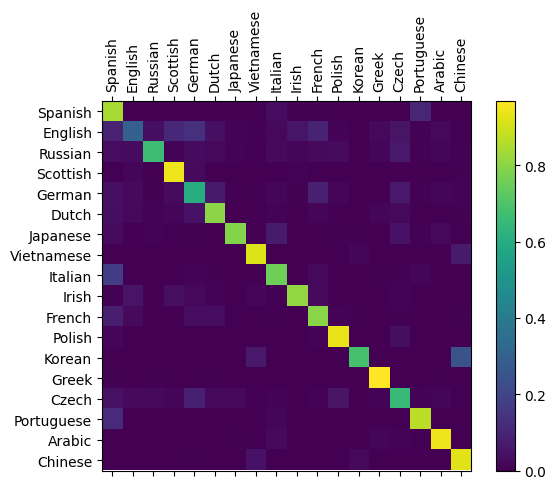

In [ ]:
compute_confusion_matrix(model)

In [ ]:
n_hidden = 64
model = LSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 17s) 2.9055 Fonseca / Spanish ✗ (Portuguese)
20000 10% (0m 34s) 2.7505 Roosevelt / Portuguese ✗ (Dutch)
30000 15% (0m 52s) 2.3497 Schwenke / French ✗ (German)
40000 20% (1m 9s) 1.8371 Bao / Vietnamese ✗ (Chinese)
50000 25% (1m 27s) 1.9061 Hausler / German ✓
60000 30% (1m 44s) 2.8672 Kauphsman / Irish ✗ (Czech)
70000 35% (2m 2s) 2.9940 Holan / Irish ✗ (Czech)
80000 40% (2m 20s) 0.3571 Christodoulou / Greek ✓
90000 45% (2m 37s) 2.8462 Kava / Japanese ✗ (Polish)
100000 50% (2m 55s) 1.1621 Czabal / Czech ✓
110000 55% (3m 13s) 2.4344 Arce / French ✗ (Spanish)
120000 60% (3m 30s) 1.6175 Woo / Korean ✗ (Chinese)
130000 65% (3m 48s) 4.6150 Berezovoi / Italian ✗ (Russian)
140000 70% (4m 5s) 1.1542 Ho / Korean ✗ (Vietnamese)
150000 75% (4m 23s) 0.1287 Rademakers / Dutch ✓
160000 80% (4m 41s) 0.6196 Nunes / Portuguese ✓
170000 85% (4m 58s) 1.1282 Russell / Scottish ✓
180000 90% (5m 16s) 1.6499 Dou / Vietnamese ✗ (Chinese)
190000 95% (5m 33s) 1.0216 Rory / English ✗ (Irish)
200000 100

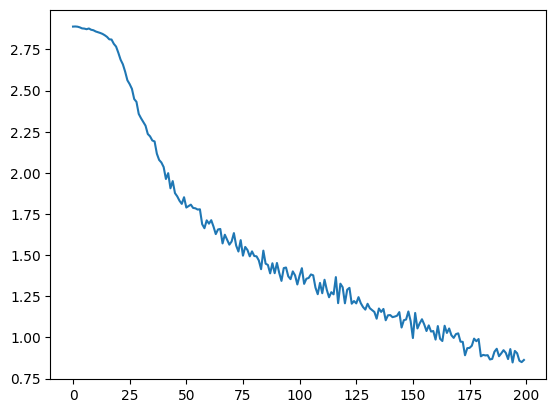

In [ ]:
plot_loss(all_losses)

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


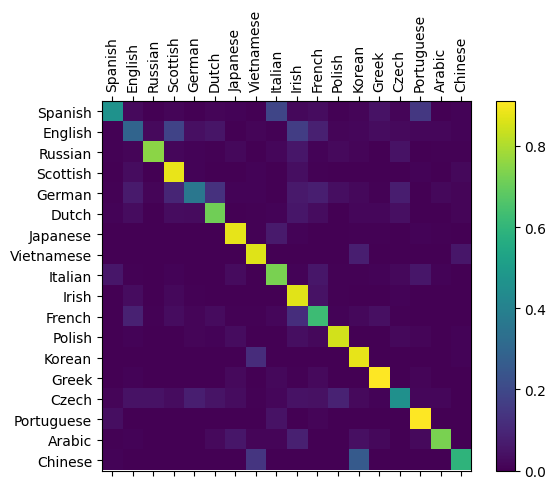

In [ ]:
compute_confusion_matrix(model)

In [ ]:
n_hidden = 40
model = BiLSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 31s) 2.9114 Altena / Scottish ✗ (Dutch)
20000 10% (1m 2s) 2.5982 Eng / Chinese ✓
30000 15% (1m 32s) 2.9799 Arce / German ✗ (Spanish)
40000 20% (2m 3s) 1.1064 Bektemirov / Russian ✓
50000 25% (2m 34s) 1.2391 Vuong / Korean ✗ (Vietnamese)
60000 30% (3m 5s) 0.3536 Teshigahara / Japanese ✓
70000 35% (3m 35s) 0.5537 Crespo / Portuguese ✓
80000 40% (4m 6s) 3.1930 Zaruba / Portuguese ✗ (Czech)
90000 45% (4m 37s) 1.2045 Zha / Vietnamese ✗ (Chinese)
100000 50% (5m 7s) 2.7058 Nasato / Japanese ✗ (Italian)
110000 55% (5m 38s) 1.6339 Manco / Spanish ✗ (Italian)
120000 60% (6m 9s) 0.7826 Guan / Chinese ✓
130000 65% (6m 39s) 1.3556 Mckeown / Scottish ✗ (English)
140000 70% (7m 10s) 1.2230 Oliver / French ✓
150000 75% (7m 41s) 0.8261 Mackenzie / Scottish ✓
160000 80% (8m 12s) 1.2114 Serafim / Portuguese ✓
170000 85% (8m 43s) 0.4222 Mochan / Irish ✓
180000 90% (9m 14s) 0.0346 Kowalski / Polish ✓
190000 95% (9m 45s) 0.7439 Tedesco / Italian ✓
200000 100% (10m 15s) 2.4732 Vespa / Czech ✗ (I

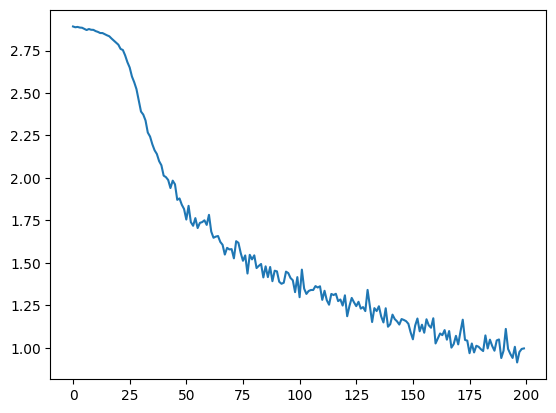

In [ ]:
plot_loss(all_losses)

/tmp/ipython-input-938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipython-input-938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


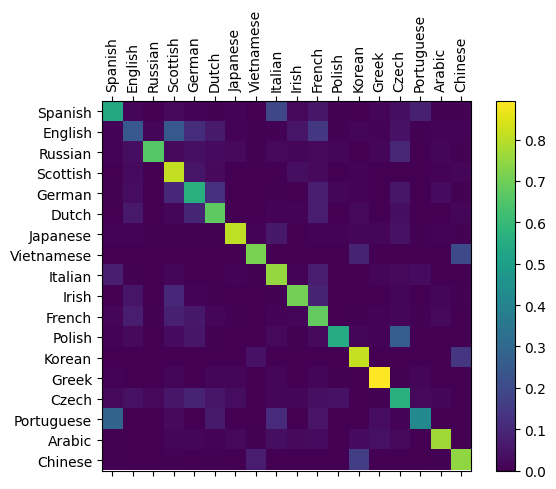

In [ ]:
compute_confusion_matrix(model)

En este caso podemos ver que no existe demasiada diferencia entre las tres arquitecturas (aunque para saberlo con certeza habría que hacer una mejor búsqueda de hiperparámetros y evaluar correctamente, lo cual no era parte de este laboratorio).
A primera vista vemos que los tres modelos parecen comportarse de manera similar. Una posible explicación es debido a que este dataset es muy pequeño y no logra aprovechar las capacidades de modelos más sofisticados como la LSTM y la BiLSTM. En escenarios más realistas (más datos y tareas más desafiantes) es esperable que la LSTM supere largamente a la RNN simple, y que la BiLSTM supere a la LSTM.

## Evaluación manual

Por completitud, a continuación dejamos un código para evaluar el modelo en ejemplos definidos manualmente, por si usted desea utilizarlo de esta manera.




In [ ]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line), model)

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Satoshi')
predict("Muñoz")
predict("Raymond")


> Dovesky
(6.86) Czech
(6.79) Russian
(5.42) English

> Jackson
(8.31) Scottish
(5.64) English
(3.40) Russian

> Satoshi
(7.88) Japanese
(4.53) Arabic
(3.91) Italian

> Muñoz
(3.49) Spanish
(3.26) Polish
(1.98) Portuguese

> Raymond
(5.36) English
(4.73) French
(4.49) Dutch


# Actividad 1

- Mencione la dimensionalidad oculta de los 3 modelos ejecutados en este laboratorio, calcule su cantidad de parámetros y explique por qué no sería justo utilizar dimensionalidad oculta pareja para todos los modelos.

# Actividad 2

Agregue otra capa lineal con una ReLU al clasificador del modelo de LSTM (no bidireccional) como se muestra en la figura.

Pruebe variantes de 50, 150 y 300 neuronas en la capa oculta.

- Grafique la pérdida para las 3 y comente.
- Calcule la cantidad de parámetros de los tres modelos y comente.

*(Consejo: debe tener dos capas `linear`, y se necesita una activación entre ellas)*

| A la izquierda se muestra diagrama actual de salida de la red. Implementar el de la izquierda agregando otra capa. |
| :--: |
| 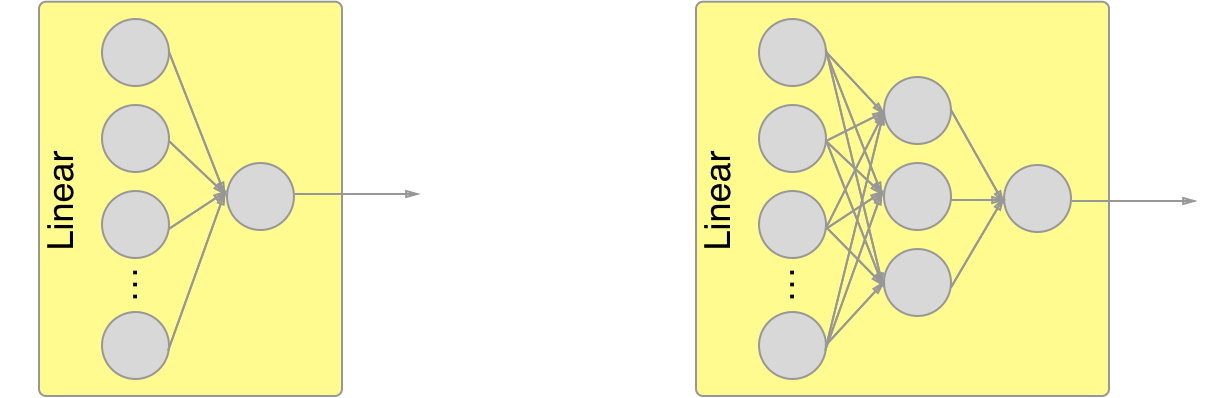 |

